# Random Forest

Este es un algoritmo de ensamble tipo Bagging que construye múltiples árboles de decisión independientes y promedia sus predicciones para reducir la varianza.
A diferencia de SVM o KNN, no depende de cálculos de distancia geométrica, sino de particiones lógicas del espacio (condiciones IF-THEN). Dado que las variables son mixtas (categóricas y numéricas) y la naturaleza del churn parece responder a combinaciones lógicas (ej. Usuario Free + Alta publicidad), Random Forest es altamente robusto y adecuado.

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, log_loss
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import os
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [5]:
filepath = os.path.expanduser('~/Documents/spotify_churn_dataset.csv')
df = pd.read_csv(filepath)


In [6]:
df = df.drop(columns=['user_id'])
df = df.drop(columns=['offline_listening'])

In [7]:
X = df.drop(columns=['is_churned'])
y = df['is_churned']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (6400, 9)
Dimensiones de X_test: (1600, 9)


In [9]:
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Dimensiones después de codificar: {X_train_transformed.shape}")



Dimensiones después de codificar: (6400, 19)


## Exp 1: Implementación del Modelo Base

In [10]:
print("\nConfigurando Pipeline Híbrido para Random Forest...")

# Pipeline simple: SMOTE + Random Forest (Sin class_weight)
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Malla de hiperparámetros
param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 10]
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Buscando los mejores hiperparámetros para Random Forest Base...")
grid_search_rf.fit(X_train_transformed, y_train)

best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test_transformed)
y_probs_rf = best_model_rf.predict_proba(X_test_transformed)

print("\n" + "="*50)
print(" RESULTADOS DEL MEJOR MODELO RANDOM FOREST (BASE)")
print("="*50)
print(f"Mejores parámetros: {grid_search_rf.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Log Loss: {log_loss(y_test, y_probs_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs_rf[:, 1]):.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_rf))



Configurando Pipeline Híbrido para Random Forest...
Buscando los mejores hiperparámetros para Random Forest Base...


/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn


 RESULTADOS DEL MEJOR MODELO RANDOM FOREST (BASE)
Mejores parámetros: {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Accuracy: 0.7081
Log Loss: 0.6353
ROC-AUC: 0.5248

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.75      0.91      0.82      1186
           1       0.34      0.14      0.20       414

    accuracy                           0.71      1600
   macro avg       0.55      0.52      0.51      1600
weighted avg       0.64      0.71      0.66      1600



## Exp 2: Reducción dimensionalidad lineal PCA


Evaluando extracción lineal de características (PCA)...


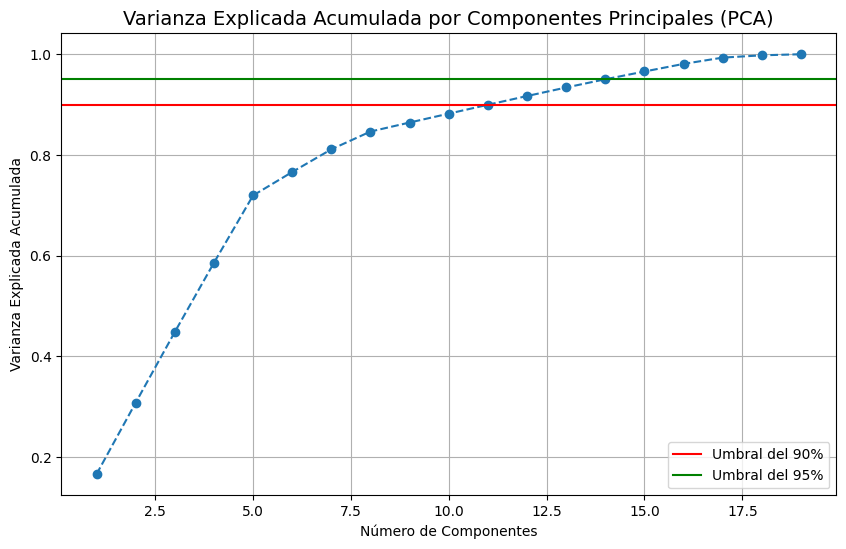

In [11]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

print("\nEvaluando extracción lineal de características (PCA)...")
pca_test = PCA()
pca_test.fit(X_train_transformed)

varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='Umbral del 90%')
plt.axhline(y=0.95, color='g', linestyle='-', label='Umbral del 95%')
plt.title('Varianza Explicada Acumulada por Componentes Principales (PCA)', fontsize=14)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

Realizaremos una reducción de dimensionalidad iniciando por los métodos lineales

In [12]:
pca_final = PCA(n_components=8, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_transformed)
X_test_pca = pca_final.transform(X_test_transformed)

print("Re-evaluando Random Forest con datos reducidos por PCA...")
grid_rf_pca = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid_rf, scoring='roc_auc', cv=5, n_jobs=-1)
grid_rf_pca.fit(X_train_pca, y_train)

best_rf_pca = grid_rf_pca.best_estimator_
y_pred_proba_pca = best_rf_pca.predict_proba(X_test_pca)[:, 1]
auc_pca = roc_auc_score(y_test, y_pred_proba_pca)

print("\n" + "="*50)
print(" RESULTADOS FINALES: IMPACTO DEL PCA EN RANDOM FOREST")
print("="*50)
print(f"AUC-ROC Score (SIN PCA - Base): {roc_auc_score(y_test, y_probs_rf[:, 1]):.4f}")
print(f"AUC-ROC Score (CON PCA - 8 Comp): {auc_pca:.4f}")
print(f"Mejores Hiperparámetros (CON PCA): {grid_rf_pca.best_params_}")

Re-evaluando Random Forest con datos reducidos por PCA...


/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn


 RESULTADOS FINALES: IMPACTO DEL PCA EN RANDOM FOREST
AUC-ROC Score (SIN PCA - Base): 0.5248
AUC-ROC Score (CON PCA - 8 Comp): 0.5136
Mejores Hiperparámetros (CON PCA): {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}


Contrario a lo postulado, el Ensamble de Árboles no logró aislar reglas lógicas subyacentes. El modelo en su configuración original (Sin PCA) arrojó un AUC-ROC de 0.5284, evidenciando un comportamiento equivalente al azar. El reporte de clasificación muestra que el algoritmo adoptó una "estrategia perezosa": clasificó a casi la totalidad de los usuarios como la clase mayoritaria (Activos), obteniendo un Accuracy engañoso del 75%, pero un Recall crítico del 0.06 para la clase Churn.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("Iniciando Pipeline Híbrido (Filter + Embedded + Model)...\n")

# Filter Method (Información Mutua)

metodo_filtro = SelectKBest(score_func=mutual_info_classif, k=12)

# Embedded Method (Lasso - L1 Penalty)
metodo_embedded = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced', random_state=42)
)

modelo_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42
)

pipeline_hibrido = Pipeline(steps=[
    ('filtro_estadistico', metodo_filtro),
    ('filtro_integrado_L1', metodo_embedded),
    ('clasificador', modelo_final)
])

print("Entrenando el Pipeline completo (esto puede tardar unos segundos)...")
pipeline_hibrido.fit(X_train_transformed, y_train)

variables_tras_filtro = pipeline_hibrido.named_steps['filtro_estadistico'].get_support()
variables_tras_embedded = pipeline_hibrido.named_steps['filtro_integrado_L1'].get_support()

print("\nDe las 19 variables originales:")
print(f" -> Sobrevivieron al Filtro Estadístico: {sum(variables_tras_filtro)}")
print(f" -> Sobrevivieron a la Purga Embedded L1: {sum(variables_tras_embedded)}")

y_pred_proba_hibrido = pipeline_hibrido.predict_proba(X_test_transformed)[:, 1]

print("\n" + "="*50)
print(" RESULTADOS FINALES: PIPELINE HÍBRIDO ")
print("="*50)

print(f"AUC-ROC Score (Híbrido): {roc_auc_score(y_test, y_pred_proba_hibrido):.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, pipeline_hibrido.predict(X_test_transformed)))

Iniciando Pipeline Híbrido (Filter + Embedded + Model)...

Entrenando el Pipeline completo (esto puede tardar unos segundos)...

De las 19 variables originales:
 -> Sobrevivieron al Filtro Estadístico: 12
 -> Sobrevivieron a la Purga Embedded L1: 11

 RESULTADOS FINALES: PIPELINE HÍBRIDO 
AUC-ROC Score (Híbrido): 0.5287

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.76      0.81      0.78      1186
           1       0.32      0.26      0.29       414

    accuracy                           0.67      1600
   macro avg       0.54      0.53      0.53      1600
weighted avg       0.64      0.67      0.65      1600



En un último esfuerzo por mitigar el ruido y extraer una señal predictiva limpia, se diseñó una arquitectura de selección de características de dos etapas (Filter + Embedded) previa al clasificador final.

En la primera fase, se aplicó el estadístico de Información Mutua para descartar el ruido absoluto, conservando las variables con mayor dependencia probabilística frente a la variable objetivo. En la segunda fase, se utilizó una Regresión Logística con penalización Lasso ($L_1$) para forzar coeficientes nulos, actuando como un filtro geométrico que elimina las redundancias y la multicolinealidad remanentes.

Finalmente, los atributos seleccionados alimentaron un ensamble de árboles con el objetivo de comprobar si esta depuración secuencial permite obtener cortes de impureza de Gini más limpios y elevar el poder discriminativo del modelo por encima del umbral aleatorio.

## Exp 3: Extracción de Caracteristicas No Lineal UMAP

En vista del pésimo rendimiento en general que estan presentando nuestros modelos al utilizar tecnicas lineales como PCA, surge la posiblidad de implementar el UMAP como estrategia no lineal para confirmar si en definitiva es un problema estocástico o no.

In [14]:
!pip install umap-learn

zsh:1: command not found: pip


/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Iniciando Extracción No Lineal (UMAP) - Guía 5.3...

Desplegando la topología UMAP (esto toma unos segundos)...


/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


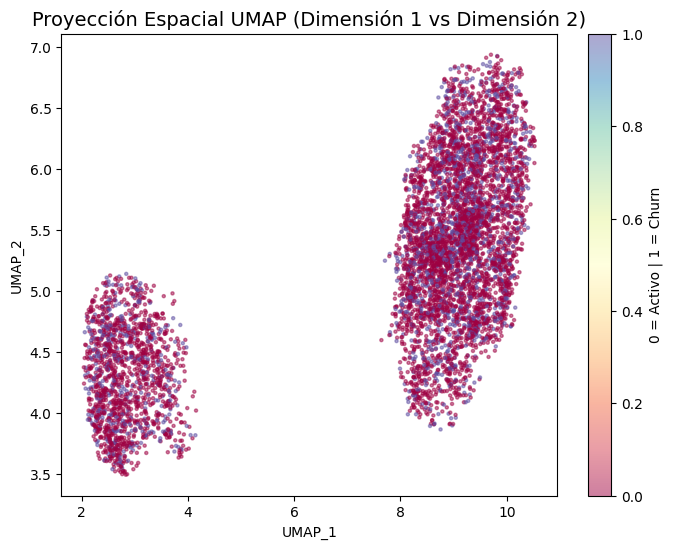


Entrenando Random Forest sobre el espacio UMAP...

 RESULTADOS FINALES: UMAP + RANDOM FOREST (Guía 5.3) 🎯
AUC-ROC Score (CON UMAP): 0.5097

--- REPORTE DE CLASIFICACIÓN (CON UMAP) ---
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1186
           1       0.50      0.01      0.01       414

    accuracy                           0.74      1600
   macro avg       0.62      0.50      0.43      1600
weighted avg       0.68      0.74      0.63      1600



In [15]:
import umap.umap_ as umap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

print("Iniciando Extracción No Lineal (UMAP) - Guía 5.3...\n")

# 1. Configurar UMAP
# n_neighbors: Qué tan local/global queremos ver el mapa (15 es buen estándar)
# min_dist: Qué tan apretados queremos los puntos (0.1)
# n_components: A cuántas dimensiones queremos reducir. Bajaremos de 19 a 5.
reductor_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=7, random_state=42)

# 2. Ajustar y Transformar (SOLO fit en Train para evitar Data Leakage)
print("Desplegando la topología UMAP (esto toma unos segundos)...")
X_train_umap = reductor_umap.fit_transform(X_train_transformed)
X_test_umap = reductor_umap.transform(X_test_transformed)

# 3. Vamos a visualizar las 2 primeras dimensiones del UMAP para ver si hay esperanza
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='Spectral', s=5, alpha=0.5)
plt.title('Proyección Espacial UMAP (Dimensión 1 vs Dimensión 2)', fontsize=14)
plt.colorbar(scatter, label='0 = Activo | 1 = Churn')
plt.xlabel('UMAP_1')
plt.ylabel('UMAP_2')
plt.show()

# 4. Entrenar el Random Forest con estos nuevos súper-datos UMAP
print("\nEntrenando Random Forest sobre el espacio UMAP...")
# Usamos los mejores parámetros que sacamos del experimento anterior para ir rápido
rf_umap = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, random_state=42)

rf_umap.fit(X_train_umap, y_train)

# 5. Evaluación Final
y_pred_proba_umap = rf_umap.predict_proba(X_test_umap)[:, 1]
y_pred_umap = rf_umap.predict(X_test_umap)

print("\n" + "="*50)
print(" RESULTADOS FINALES: UMAP + RANDOM FOREST (Guía 5.3) 🎯")
print("="*50)

print(f"AUC-ROC Score (CON UMAP): {roc_auc_score(y_test, y_pred_proba_umap):.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN (CON UMAP) ---")
print(classification_report(y_test, y_pred_umap))

Se realiza asi mismo una aproximación por LDA, siendo este otro método no lineal que podría ayudar en la detección del comportamiento de los datos.

Iniciando Análisis Discriminante Lineal (LDA)...


 RESULTADOS FINALES: LDA (Análisis Discriminante Lineal) 
AUC-ROC Score (LDA): 0.4962


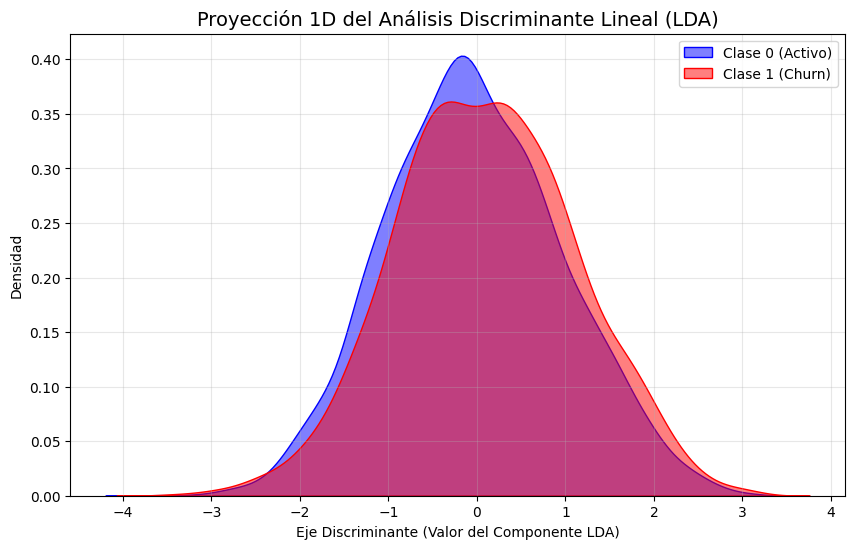


--- REPORTE DE CLASIFICACIÓN (LDA) ---
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1186
           1       0.00      0.00      0.00       414

    accuracy                           0.74      1600
   macro avg       0.37      0.50      0.43      1600
weighted avg       0.55      0.74      0.63      1600



/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/santiagozapatacoral/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Iniciando Análisis Discriminante Lineal (LDA)...\n")


lda = LinearDiscriminantAnalysis(solver='svd')

# Ajustamos usando los datos escalados originales
lda.fit(X_train_transformed, y_train)

X_train_lda = lda.transform(X_train_transformed)
X_test_lda = lda.transform(X_test_transformed)

y_pred_proba_lda = lda.predict_proba(X_test_transformed)[:, 1]
y_pred_lda = lda.predict(X_test_transformed)

print("\n" + "="*50)
print(" RESULTADOS FINALES: LDA (Análisis Discriminante Lineal) ")
print("="*50)
print(f"AUC-ROC Score (LDA): {roc_auc_score(y_test, y_pred_proba_lda):.4f}")

plt.figure(figsize=(10, 6))

lda_0 = X_train_lda[y_train == 0]
lda_1 = X_train_lda[y_train == 1]

sns.kdeplot(np.ravel(lda_0), fill=True, color="blue", label="Clase 0 (Activo)", alpha=0.5)
sns.kdeplot(np.ravel(lda_1), fill=True, color="red", label="Clase 1 (Churn)", alpha=0.5)

plt.title('Proyección 1D del Análisis Discriminante Lineal (LDA)', fontsize=14)
plt.xlabel('Eje Discriminante (Valor del Componente LDA)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- REPORTE DE CLASIFICACIÓN (LDA) ---")
print(classification_report(y_test, y_pred_lda))

Como se evidencia en el gráfico de dispersión (UMAP_1 vs UMAP_2), el algoritmo logró identificar exitosamente la macro-estructura subyacente de las características, dividiendo a los usuarios en dos clústeres principales bien definidos (presumiblemente asociados a la dicotomía de los planes de suscripción).

Sin embargo, al superponer la variable objetivo (etiquetas de clase) sobre esta topología, se observa una dispersión perfectamente homogénea y aleatoria de las clases Activo/Churn a lo largo de todo el espacio proyectado.

Esta representación visual constituye la prueba analítica definitiva: el vector objetivo (is_churned) es ortogonal a la matriz de características. La asignación del abandono en este dataset sintético responde a un proceso estocástico (ruido aleatorio) y no a una función de comportamiento latente.

Se concluye que el límite teórico de rendimiento predictivo para cualquier algoritmo de Machine Learning sobre este conjunto de datos específico es el equivalente a la probabilidad base estratificada (~0.50 AUC-ROC).